STEP 1 — Import Libraries

In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 2 — Load Cleaned Dataset

In [2]:
# ===============================
# LOAD CLEANED DATASET
# ===============================

df = pd.read_csv("../data/cleaned_tgspdcl_data.csv")

print("Cleaned dataset loaded successfully.")

display(df.head())

Cleaned dataset loaded successfully.


,circle,division,subdivision,section,area,catdesc,catcode,totservices,billdservices,units,load,units_per_service,service_utilization_ratio,avg_load_per_service,load_efficiency
0,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,MAHATMA NAGAR,NON-DOMESTIC AND COMMERCIAL,2,24,22.0,3334,30.44,138.916667,0.916667,1.268333,109.526938
1,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM -I (S),NON-DOMESTIC AND COMMERCIAL,2,77,76.0,9443,117.27,122.636364,0.987013,1.522987,80.523578
2,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - II,NON-DOMESTIC AND COMMERCIAL,2,24,23.0,3242,29.74,135.083333,0.958333,1.239167,109.011432
3,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - III,NON-DOMESTIC AND COMMERCIAL,2,105,101.0,16863,144.92,160.600000,0.961905,1.380190,116.360751
4,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE -I,NON-DOMESTIC AND COMMERCIAL,2,101,99.0,6767,101.00,67.000000,0.980198,1.000000,67.000000


STEP 3 — Executive KPI Summary

In [3]:
# ===============================
# EXECUTIVE KPI SUMMARY
# ===============================

total_units = df['units'].sum()

total_load = df['load'].sum()

total_services = df['totservices'].sum()

avg_efficiency = df['load_efficiency'].mean()

print("===== EXECUTIVE KPI SUMMARY =====")

print(f"Total Units Consumed: {total_units:,.2f}")

print(f"Total Load: {total_load:,.2f}")

print(f"Total Services: {total_services:,.0f}")

print(f"Average Load Efficiency: {avg_efficiency:.2f}")

===== EXECUTIVE KPI SUMMARY =====
Total Units Consumed: 367,785,855.00
Total Load: 4,857,927.85
Total Services: 1,375,703
Average Load Efficiency: 64.47


STEP 4 — Top 15 Areas by Consumption

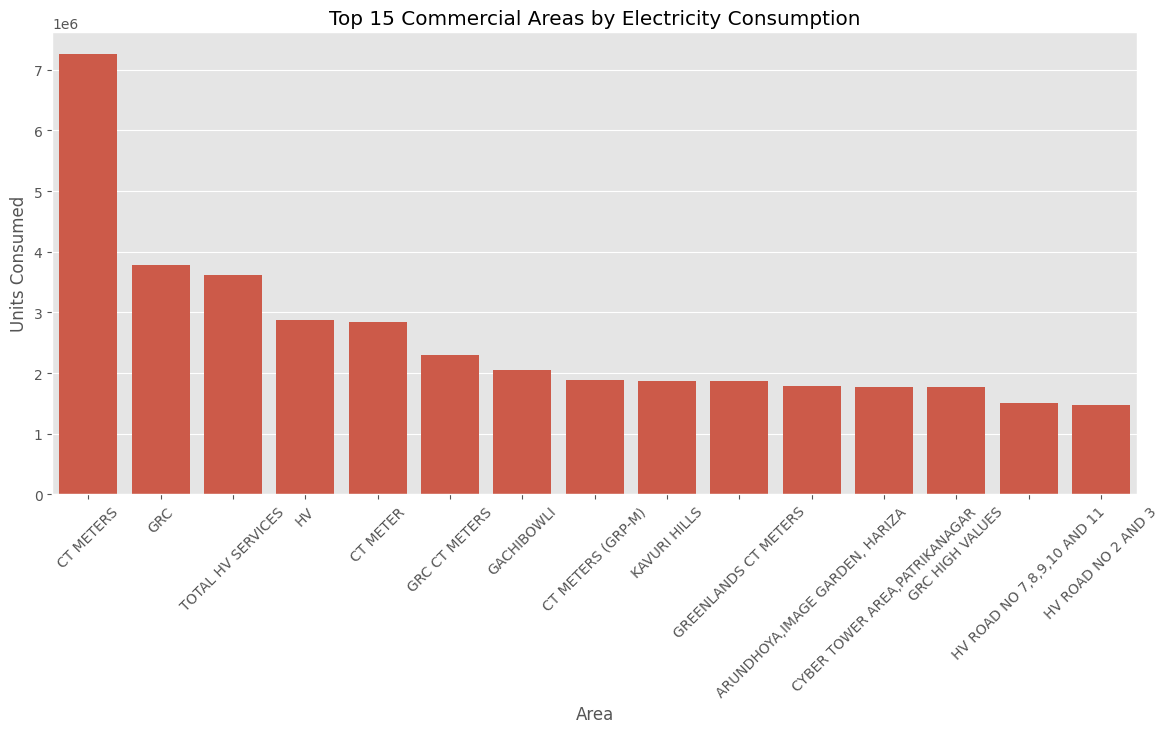

In [4]:
# ===============================
# TOP 15 AREAS BY CONSUMPTION
# ===============================

top_areas = (
    df.groupby('area')['units']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_areas.index,
    y=top_areas.values
)

plt.title("Top 15 Commercial Areas by Electricity Consumption")

plt.xlabel("Area")

plt.ylabel("Units Consumed")

plt.xticks(rotation=45)

plt.show()

STEP 5 — Circle-wise Efficiency Ranking

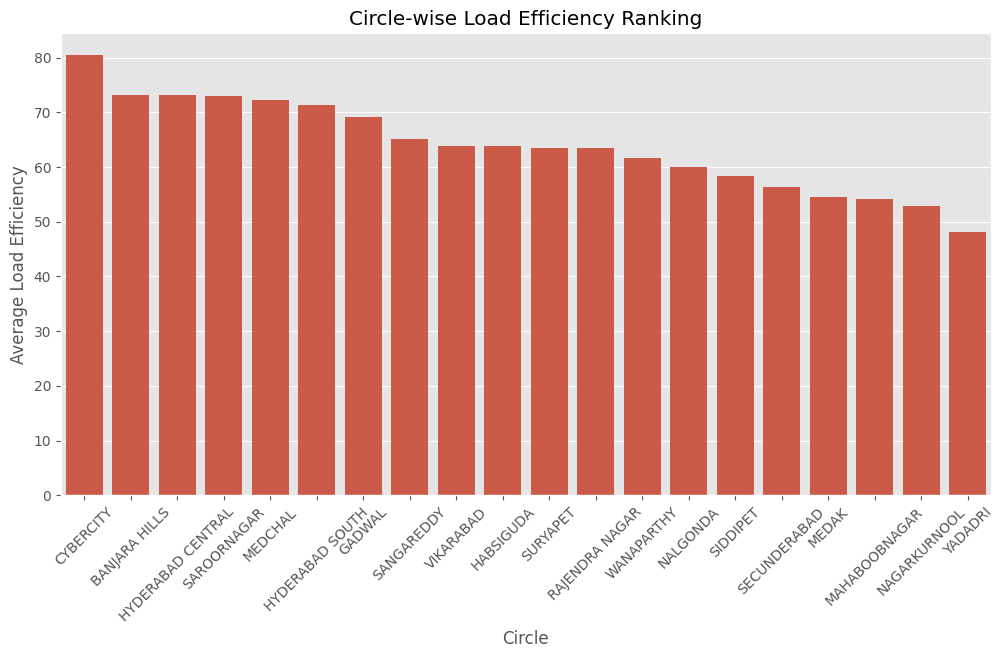

In [5]:
# ===============================
# CIRCLE-WISE EFFICIENCY
# ===============================

circle_efficiency = (
    df.groupby('circle')['load_efficiency']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=circle_efficiency.index,
    y=circle_efficiency.values
)

plt.title("Circle-wise Load Efficiency Ranking")

plt.xlabel("Circle")

plt.ylabel("Average Load Efficiency")

plt.xticks(rotation=45)

plt.show()

STEP 6 — Division-wise Service Utilization

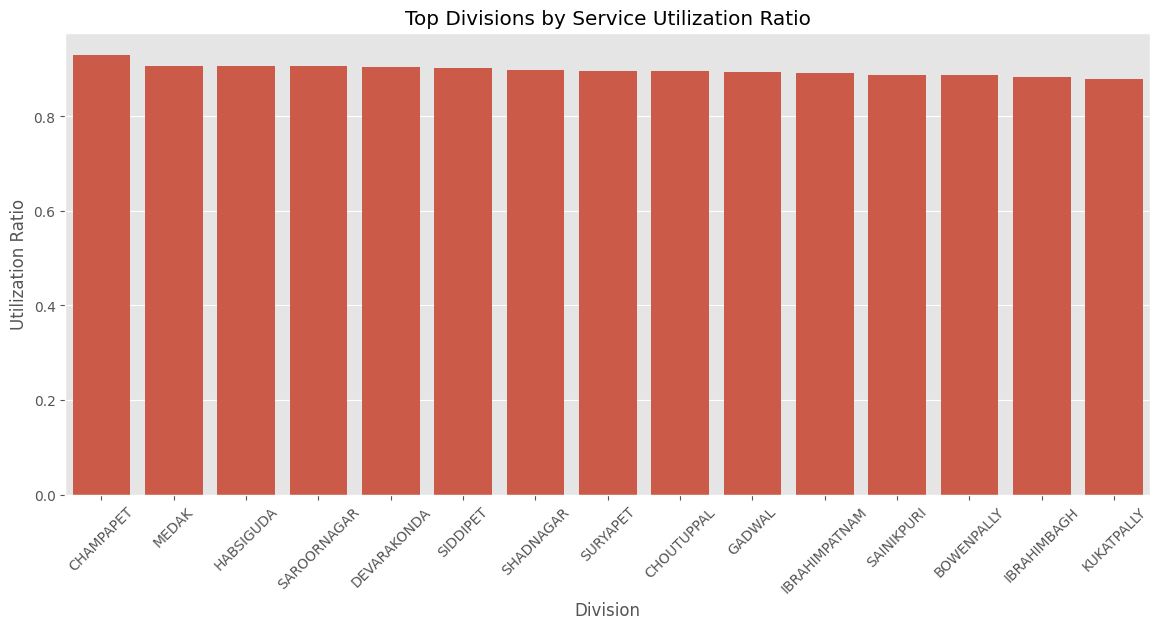

In [6]:
# ===============================
# DIVISION SERVICE UTILIZATION
# ===============================

division_utilization = (
    df.groupby('division')['service_utilization_ratio']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=division_utilization.index,
    y=division_utilization.values
)

plt.title("Top Divisions by Service Utilization Ratio")

plt.xlabel("Division")

plt.ylabel("Utilization Ratio")

plt.xticks(rotation=45)

plt.show()

STEP 7 — High Load Risk Areas

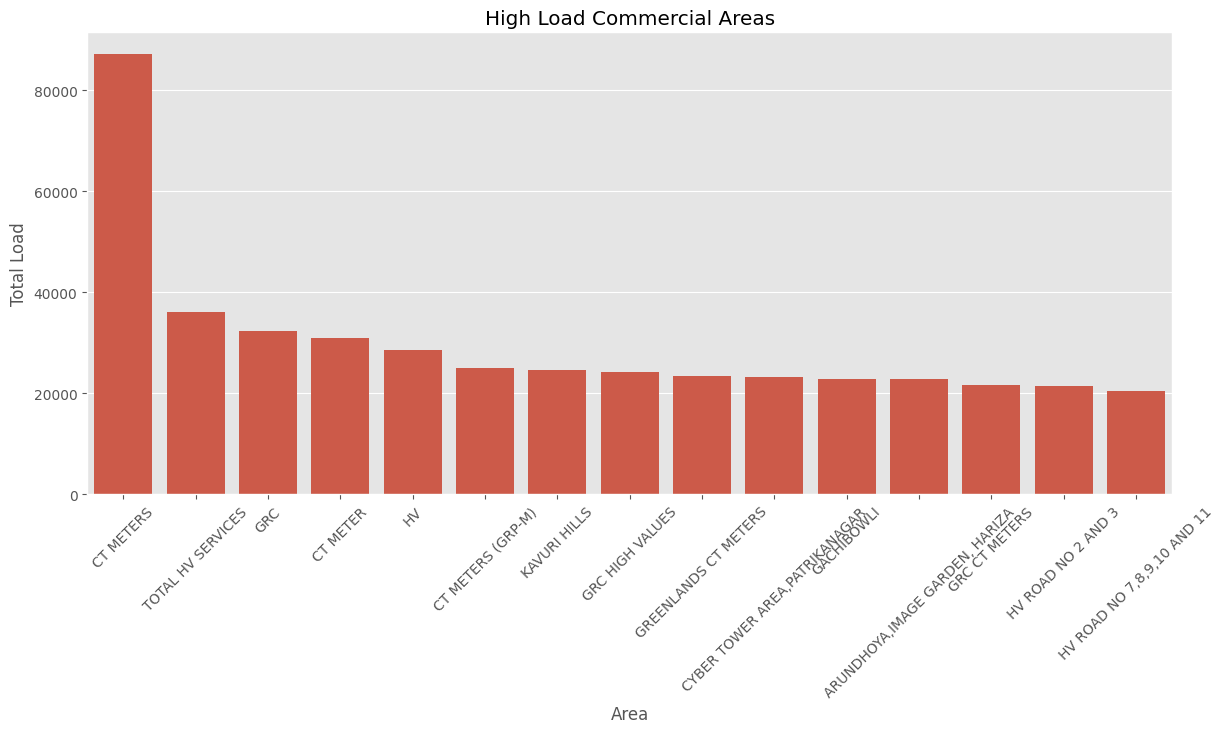

In [7]:
# ===============================
# HIGH LOAD RISK AREAS
# ===============================

high_load_areas = (
    df.groupby('area')['load']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=high_load_areas.index,
    y=high_load_areas.values
)

plt.title("High Load Commercial Areas")

plt.xlabel("Area")

plt.ylabel("Total Load")

plt.xticks(rotation=45)

plt.show()

STEP 8 — Units Per Service Distribution

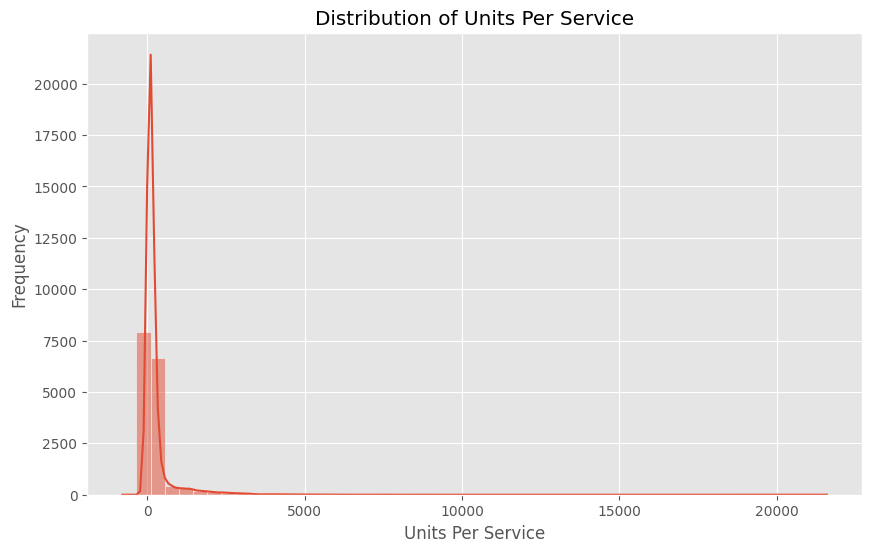

In [8]:
# ===============================
# UNITS PER SERVICE DISTRIBUTION
# ===============================

plt.figure(figsize=(10,6))

sns.histplot(
    df['units_per_service'],
    bins=50,
    kde=True
)

plt.title("Distribution of Units Per Service")

plt.xlabel("Units Per Service")

plt.ylabel("Frequency")

plt.show()

STEP 9 — Correlation Matrix

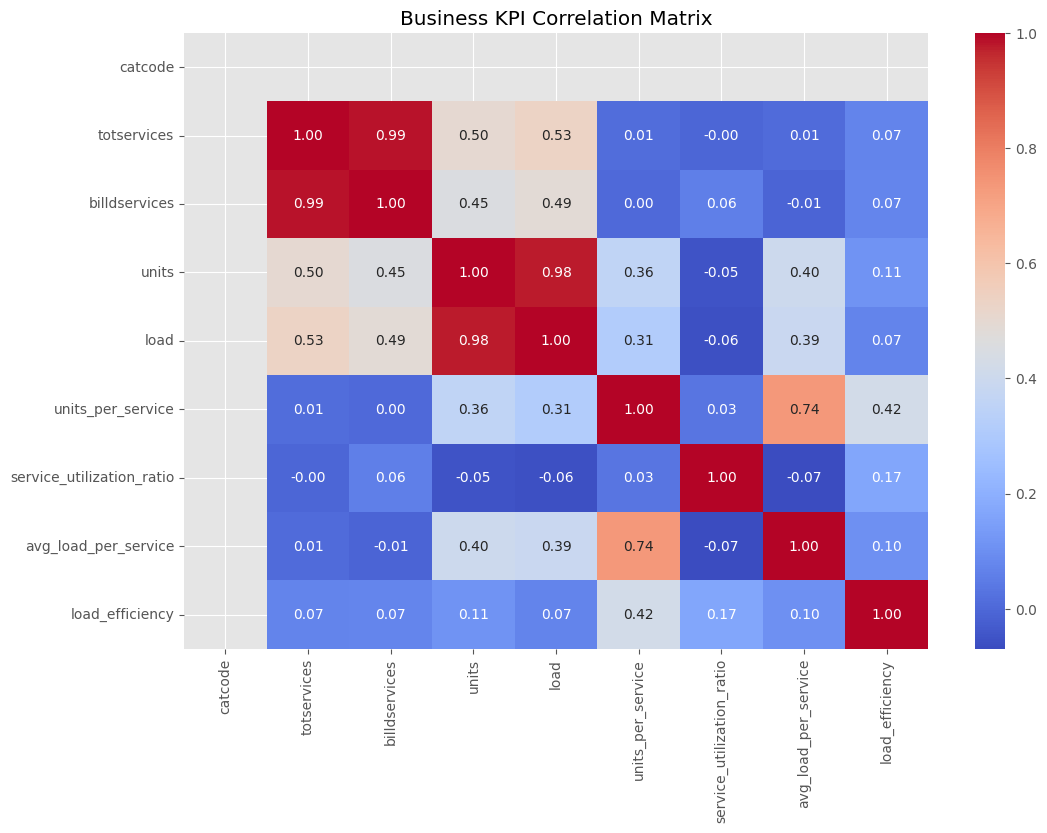

In [9]:
# ===============================
# CORRELATION MATRIX
# ===============================

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Business KPI Correlation Matrix")

plt.show()

STEP 10 — Efficiency Segmentation

In [10]:
# ===============================
# EFFICIENCY SEGMENTATION
# ===============================

conditions = [
    df['load_efficiency'] >= 100,
    (df['load_efficiency'] >= 50) &
    (df['load_efficiency'] < 100),
    df['load_efficiency'] < 50
]

labels = [
    'HIGH EFFICIENCY',
    'MEDIUM EFFICIENCY',
    'LOW EFFICIENCY'
]

df['efficiency_category'] = np.select(
    conditions,
    labels,
    default='UNKNOWN'
)

display(df[['area', 'load_efficiency', 'efficiency_category']].head())

,area,load_efficiency,efficiency_category
0,MAHATMA NAGAR,109.526938,HIGH EFFICIENCY
1,N.R.R.PURAM -I (S),80.523578,MEDIUM EFFICIENCY
2,N.R.R.PURAM SITE - II,109.011432,HIGH EFFICIENCY
3,N.R.R.PURAM SITE - III,116.360751,HIGH EFFICIENCY
4,N.R.R.PURAM SITE -I,67.000000,MEDIUM EFFICIENCY


STEP 11 — Efficiency Category Count

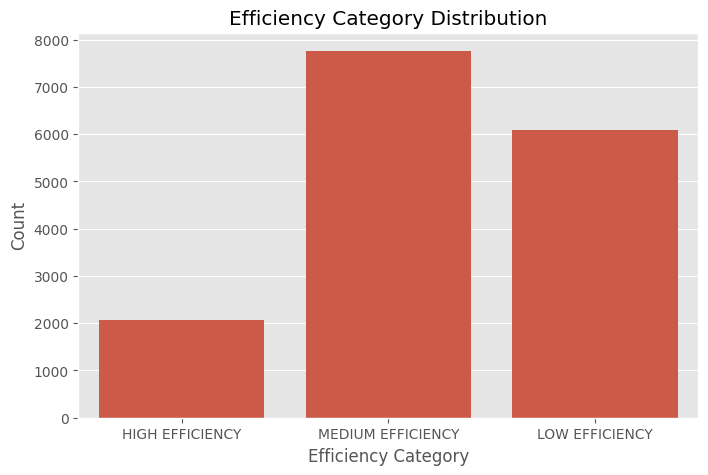

In [11]:
# ===============================
# EFFICIENCY CATEGORY COUNT
# ===============================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='efficiency_category'
)

plt.title("Efficiency Category Distribution")

plt.xlabel("Efficiency Category")

plt.ylabel("Count")

plt.show()

STEP 12 — Export Advanced Dataset

In [12]:
# ===============================
# EXPORT ADVANCED DATASET
# ===============================

df.to_csv(
    "../data/final_energy_dataset.csv",
    index=False
)

print("Final enterprise dataset exported successfully.")

Final enterprise dataset exported successfully.
